In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data=fetch_california_housing(as_frame=True)

In [ ]:
df =data.frame
print("Dataset Shape",df.shape)
df.head()

Dataset Shape (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
x=df[["AveRooms"]]
y=df[["MedHouseVal"]]
print("Input Features")
display(x.head())
print("Output Features")
display(y.head())

Input Features


,AveRooms
0,6.984127
1,6.238137
2,8.288136
3,5.817352
4,6.281853


Output Features


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model =LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
print("Intercept:", round(model.intercept_[0], 4))
print("Slope:", round(model.coef_[0][0], 4))
print(f"\nHouse Price = {model.intercept_[0]:.4f} + ({model.coef_[0][0]:.4f} * AveRooms)")

Intercept: 1.6548
Slope: 0.0768

House Price = 1.6548 + (0.0768 * AveRooms)


In [ ]:
y_pred=model.predict(x_test)
print(y_pred[:10])

[[1.97653709]
 [2.04156313]
 [1.96003112]
 [2.12785581]
 [2.07638001]
 [2.05784293]
 [2.13231401]
 [2.03568685]
 [1.95600167]
 [2.18276827]]


In [ ]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("R-squared:",r2)

Mean Squared Error: 1.2923314440807299
R-squared: 0.013795337532284901


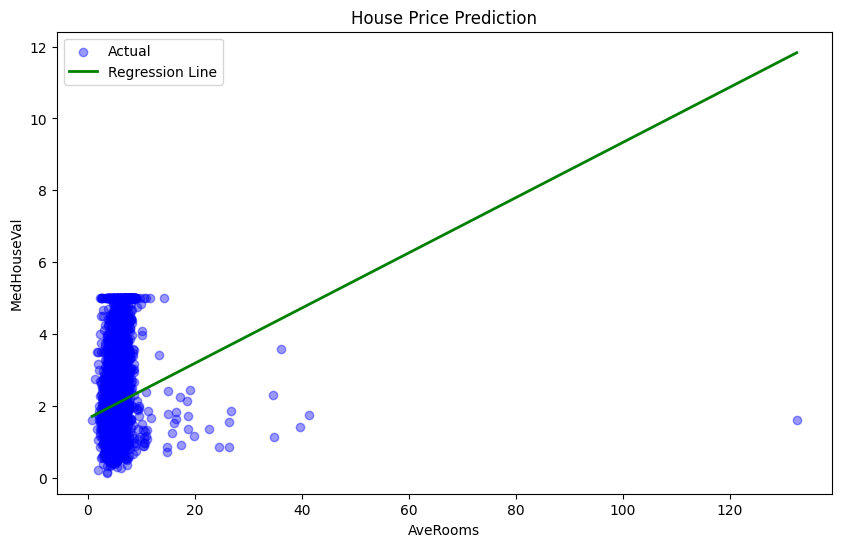

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(x_test,y_test,color='blue',label='Actual',alpha=.4)
x_sorted=x_test.sort_values('AveRooms')
plt.plot(x_sorted,model.predict(x_sorted),color='Green',linewidth=2,label="Regression Line")
plt.xlabel("AveRooms")
plt.ylabel("MedHouseVal")
plt.title("House Price Prediction")
plt.legend()
plt.show()